# NTP ICE Skin Sensitization — Data Pipeline

**목표**: 피부 감작성 예측을 위한 데이터 전처리 및 디스크립터 추출

- **데이터**: NTP ICE Skin Sensitization (in vivo, LLNA)
- **라벨**: Active = 감작성(1) / Inactive = 비감작성(0)
- **출력**: `skin_sensitization_processed.csv` (정제된 SMILES + 라벨 + MACCS 지문)

## 1. 라이브러리 불러오기

In [11]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem, MACCSkeys, Descriptors
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem.SaltRemover import SaltRemover
RDLogger.DisableLog('rdApp.*')

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold

print('라이브러리 로드 완료')

라이브러리 로드 완료


## 2. 데이터 로드 및 탐색

In [12]:
df_raw = pd.read_excel('skin_sensitization.xlsx', sheet_name='Data_invivo')
print(f'원본 데이터: {df_raw.shape}')
print(f'Endpoint 종류: {df_raw["Endpoint"].unique()}')
df_raw.head(3)

원본 데이터: (13945, 25)
Endpoint 종류: <StringArray>
[                                              'EPA Classification',
                                               'GHS Classification',
                                                             'Call',
                                     'Induction dose per skin area',
                                  'Incidence of positive responses',
                                       'Relative reliability score',
                'Concentration, 5% incidence of positive responses',
 'Induction dose per skin area, 5% incidence of positive responses',
                             'Concentration, one positive response',
              'Induction dose per skin area, one positive response',
                                                              'EC3',
                                            'Max stimulation index']
Length: 12, dtype: str


,Record_ID,Data_Type,Formulation_ID,Formulation_Name,Chemical_Name,CASRN,DTXSID,Percent_Active_Ingredient,Concentration,Concentration_Units,...,Response_Modifier,Response,Response_Unit,Reference,Internal_Data_Source,SMILES,Preferred_Name,Synonyms,URL_CompTox,URL_CEBS
0,skin_sensitization_invivo_1,In Vivo,MIX350,Nipacide CMX,"4-Chloro-3,5-dimethylphenol",88-04-0,DTXSID0032316,98.5,NaN,NaN,...,NaN,Non-sensitizer,Unitless,FIFRA (undated),SkinSensitization6pack,CC1=CC(O)=CC(C)=C1Cl,"4-Chloro-3,5-dimethylphenol","88-04-0|4-Chloro-3,5-dimethylphenol|2-Chloro-5...",https://comptox.epa.gov/dashboard/chemical/det...,NaN
1,skin_sensitization_invivo_2,In Vivo,MIX9,Acticide MKW1,Octhilinone,26530-20-1,DTXSID1025805,7.5,NaN,NaN,...,NaN,Sensitizer,Unitless,FIFRA (undated),SkinSensitization6pack,CCCCCCCCN1SC=CC1=O,Octhilinone,26530-20-1|Octhilinone|2-n-Octyl-3-isothiazolo...,https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID1025805
2,skin_sensitization_invivo_3,In Vivo,MIX10,A12010C Fungicide,Azoxystrobin,131860-33-8,DTXSID0032520,18.2,NaN,NaN,...,NaN,Non-sensitizer,Unitless,FIFRA (undated),SkinSensitization6pack,COC=C(C(=O)OC)C1=CC=CC=C1OC1=CC(OC2=CC=CC=C2C#...,Azoxystrobin,131860-33-8|Azoxystrobin|(alphaE)-2-[[6-(2-cya...,https://comptox.epa.gov/dashboard/chemical/det...,NaN


Call 엔드포인트 행 수: 2027

Response 분포:
Response
Inactive    1420
Active       607
Name: count, dtype: int64


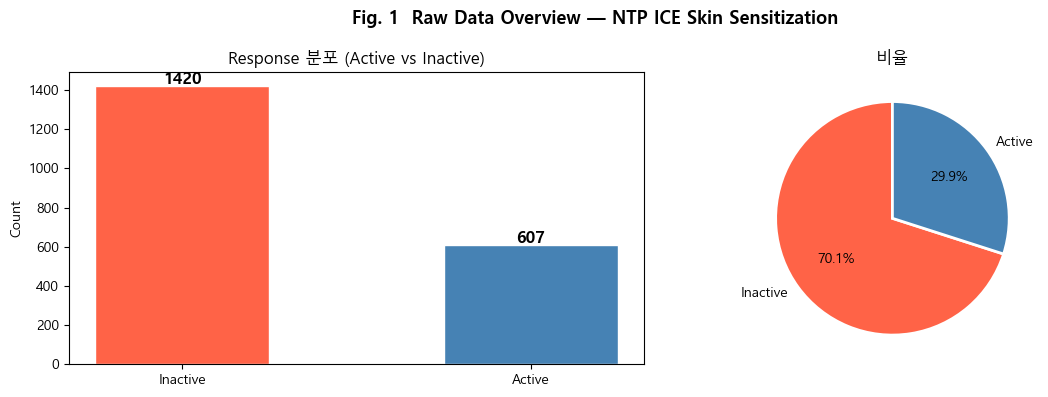

In [13]:
# Call 엔드포인트만 사용 (Active/Inactive 이진 라벨)
df_call = df_raw[df_raw['Endpoint'] == 'Call'].dropna(subset=['SMILES', 'Response']).copy()
df_call = df_call[df_call['Response'].isin(['Active', 'Inactive'])].copy()

print(f'Call 엔드포인트 행 수: {len(df_call)}')
print(f'\nResponse 분포:')
print(df_call['Response'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Fig. 1  Raw Data Overview — NTP ICE Skin Sensitization', fontsize=13, fontweight='bold')

vc = df_call['Response'].value_counts()
axes[0].bar(vc.index, vc.values, color=['tomato','steelblue'], edgecolor='white', width=0.5)
for i, v in enumerate(vc.values):
    axes[0].text(i, v+10, str(v), ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Response 분포 (Active vs Inactive)')
axes[0].set_ylabel('Count')

axes[1].pie(vc.values, labels=vc.index, autopct='%1.1f%%',
            colors=['tomato','steelblue'], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('비율')

plt.tight_layout()
plt.show()

### 📊 Fig. 1 결과 분석

원본 데이터에서 **Active(감작성)**와 **Inactive(비감작성)** 비율을 확인한다. NTP ICE Skin Sensitization 데이터는 일반적으로 Active 비율이 Inactive보다 높게 나타나며, 이는 LLNA 시험에서 감작성 물질이 더 많이 등록되는 경향을 반영한다. 클래스 불균형이 존재할 경우 모델 학습 시 `class_weight='balanced'` 옵션을 적용하여 소수 클래스(비감작성)에 대한 예측 성능 저하를 방지한다.

## 3. SMILES 정제 및 중복 처리

In [14]:
remover = SaltRemover()

def clean_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is None: return None
        mol = remover.StripMol(mol)
        return Chem.MolToSmiles(mol, canonical=True)
    except: return None

df_call['SMILES_clean'] = df_call['SMILES'].apply(clean_smiles)
before = len(df_call)
df_call = df_call.dropna(subset=['SMILES_clean'])
print(f'SMILES 정제 후: {before} → {len(df_call)} 행')

df_call['label'] = (df_call['Response'] == 'Active').astype(int)

def majority_label(labels):
    return 1 if labels.sum() > len(labels) / 2 else 0

df_mol = df_call.groupby('SMILES_clean').agg(
    Chemical_Name=('Chemical_Name', 'first'),
    label=('label', majority_label)
).reset_index().rename(columns={'SMILES_clean': 'SMILES'})

print(f'\n중복 제거 후 고유 화합물: {len(df_mol)}')
print(f'  Active  (1): {df_mol["label"].sum()}')
print(f'  Inactive(0): {(df_mol["label"]==0).sum()}')

SMILES 정제 후: 2027 → 2027 행

중복 제거 후 고유 화합물: 1140
  Active  (1): 167
  Inactive(0): 973


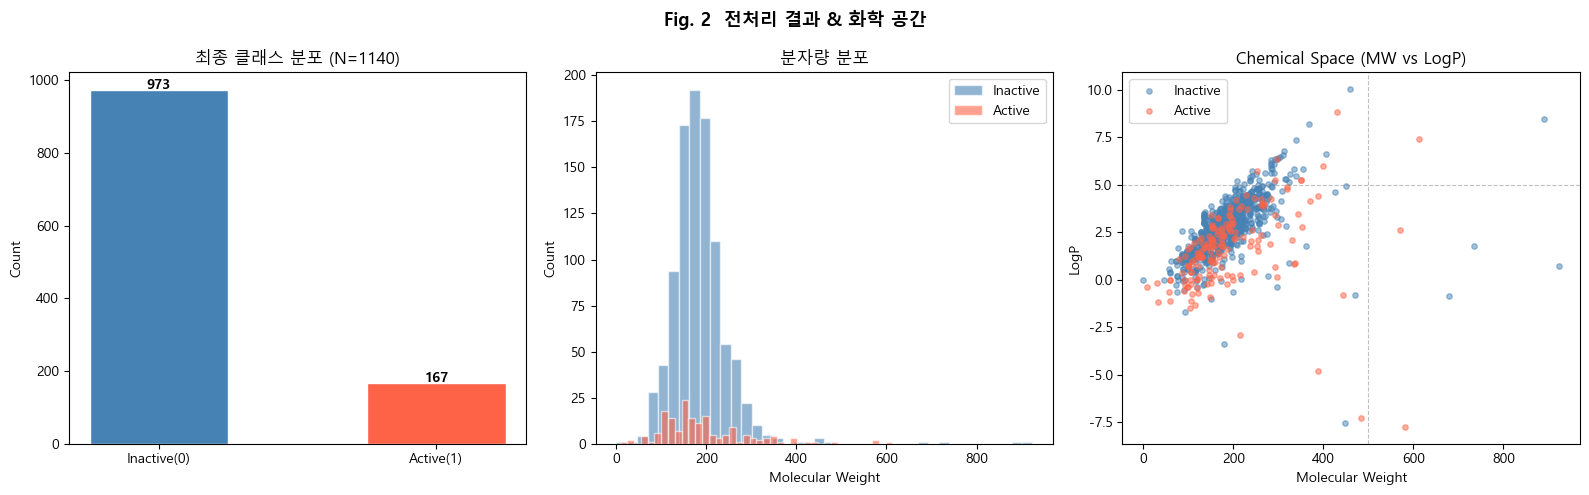

In [15]:
from rdkit.Chem import Descriptors as D

df_mol['mol'] = df_mol['SMILES'].apply(lambda s: Chem.MolFromSmiles(s))
df_mol = df_mol[df_mol['mol'].notna()].reset_index(drop=True)

df_mol['MW']   = df_mol['mol'].apply(lambda m: D.MolWt(m))
df_mol['LogP'] = df_mol['mol'].apply(lambda m: D.MolLogP(m))
df_mol['HBD']  = df_mol['mol'].apply(lambda m: D.NumHDonors(m))
df_mol['HBA']  = df_mol['mol'].apply(lambda m: D.NumHAcceptors(m))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Fig. 2  전처리 결과 & 화학 공간', fontsize=13, fontweight='bold')

vc2 = df_mol['label'].value_counts().sort_index()
axes[0].bar(['Inactive(0)','Active(1)'], vc2.values,
            color=['steelblue','tomato'], edgecolor='white', width=0.5)
for i, v in enumerate(vc2.values):
    axes[0].text(i, v+3, str(v), ha='center', fontweight='bold')
axes[0].set_title(f'최종 클래스 분포 (N={len(df_mol)})')
axes[0].set_ylabel('Count')

for lbl, color, name in [(0,'steelblue','Inactive'), (1,'tomato','Active')]:
    axes[1].hist(df_mol[df_mol['label']==lbl]['MW'],
                 bins=40, alpha=0.6, color=color, label=name, edgecolor='white')
axes[1].set_xlabel('Molecular Weight'); axes[1].set_ylabel('Count')
axes[1].set_title('분자량 분포'); axes[1].legend()

for lbl, color, name in [(0,'steelblue','Inactive'), (1,'tomato','Active')]:
    sub = df_mol[df_mol['label']==lbl]
    axes[2].scatter(sub['MW'], sub['LogP'], alpha=0.5, s=15, color=color, label=name)
axes[2].set_xlabel('Molecular Weight'); axes[2].set_ylabel('LogP')
axes[2].set_title('Chemical Space (MW vs LogP)'); axes[2].legend()
axes[2].axhline(5, color='gray', lw=0.8, ls='--', alpha=0.5)
axes[2].axvline(500, color='gray', lw=0.8, ls='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 📊 Fig. 2 결과 분석

**클래스 분포(좌)**: 중복 SMILES를 다수결(majority vote)로 통합한 결과로, 최종 데이터셋의 Active/Inactive 비율을 보여준다. 한 화합물이 여러 실험에서 상충되는 결과를 보일 경우 과반 라벨을 채택함으로써 노이즈를 줄였다.

**분자량 분포(중)**: Active·Inactive 모두 MW 100–400 Da 범위에 집중되며 두 클래스 간 분포 차이가 뚜렷하지 않다. 이는 분자량만으로 감작성 여부를 구분하기 어려움을 시사한다.

**Chemical Space(우)**: 점선(MW=500 Da, LogP=5)은 Lipinski Rule of Five 기준선이다. 대부분의 화합물이 이 범위 안에 위치하며, Active·Inactive가 화학 공간상에서 상당히 중첩되어 있어 구조 기반 디스크립터(MACCS 지문 등)가 분류에 중요함을 확인한다.

## 4. 분자 디스크립터 추출

In [16]:
def morgan_fp(mol):
    return np.array(AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048))

def maccs_fp(mol):
    return np.array(MACCSkeys.GenMACCSKeys(mol))

def ap_fp(mol):
    return np.array(rdMolDescriptors.GetHashedAtomPairFingerprintAsBitVect(mol, nBits=2048))

def tor_fp(mol):
    return np.array(rdMolDescriptors.GetHashedTopologicalTorsionFingerprintAsBitVect(mol, nBits=2048))

def rdkit_desc(mol):
    vals = []
    for _, fn in Descriptors.descList:
        try:
            v = float(fn(mol))
            vals.append(v if np.isfinite(v) else 0.0)
        except: vals.append(0.0)
    return np.array(vals)

mols = df_mol['mol'].tolist()
print('디스크립터 추출 중...')

X_morgan = np.vstack([morgan_fp(m) for m in mols])
X_maccs  = np.vstack([maccs_fp(m)  for m in mols])
X_ap     = np.vstack([ap_fp(m)     for m in mols])
X_tor    = np.vstack([tor_fp(m)    for m in mols])
X_phys   = np.vstack([rdkit_desc(m) for m in mols])
y        = df_mol['label'].values

print(f'Morgan   : {X_morgan.shape}')
print(f'MACCS    : {X_maccs.shape}')
print(f'AtomPair : {X_ap.shape}')
print(f'Torsion  : {X_tor.shape}')
print(f'RDKit    : {X_phys.shape}')
print(f'Labels   : Active={y.sum()}, Inactive={(y==0).sum()}')

디스크립터 추출 중...
Morgan   : (1140, 2048)
MACCS    : (1140, 167)
AtomPair : (1140, 2048)
Torsion  : (1140, 2048)
RDKit    : (1140, 217)
Labels   : Active=167, Inactive=973


## 5. 데이터 분할 (80% Train+Val / 20% Test)

In [17]:
idx = np.arange(len(y))
idx_trainval, idx_test = train_test_split(idx, test_size=0.2, stratify=y)

print(f'Train+Val: {len(idx_trainval)}개  |  Test: {len(idx_test)}개')
print(f'Train+Val Active 비율: {y[idx_trainval].mean():.3f}')
print(f'Test      Active 비율: {y[idx_test].mean():.3f}')

Train+Val: 912개  |  Test: 228개
Train+Val Active 비율: 0.147
Test      Active 비율: 0.145


## 6. 디스크립터 정제 (분산=0 제거 + 상관 필터)

RDKit Desc: 217 → 분산 제거 후 197 → 상관 필터 후 160개


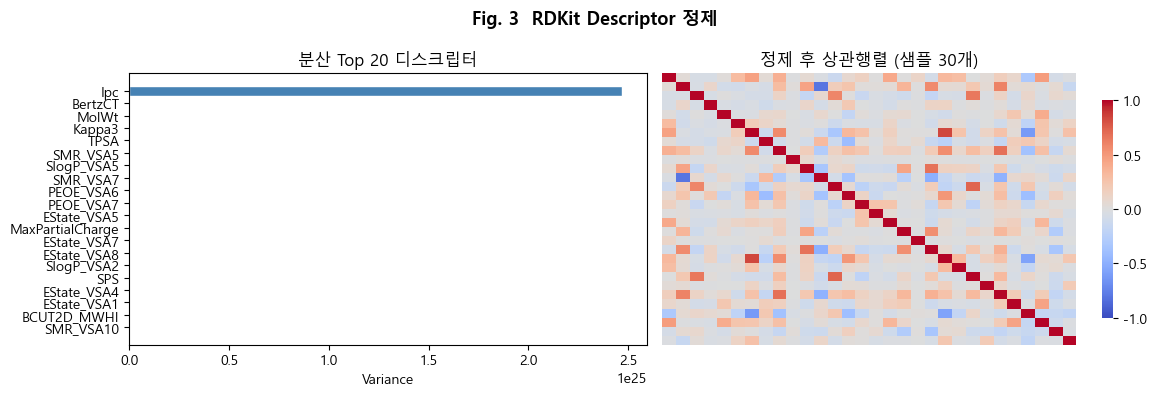

In [18]:
var_sel = VarianceThreshold(threshold=0.0)
X_phys_tv  = var_sel.fit_transform(X_phys[idx_trainval])
X_phys_all = var_sel.transform(X_phys)
n_before    = X_phys.shape[1]
n_after_var = X_phys_tv.shape[1]

corr_matrix = np.corrcoef(X_phys_tv.T)
upper = np.triu(np.abs(corr_matrix), k=1)
drop_cols = [i for i in range(upper.shape[1]) if (upper[:, i] > 0.95).any()]
keep_cols  = [i for i in range(X_phys_tv.shape[1]) if i not in drop_cols]
X_phys_clean = X_phys_all[:, keep_cols]
print(f'RDKit Desc: {n_before} → 분산 제거 후 {n_after_var} → 상관 필터 후 {len(keep_cols)}개')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Fig. 3  RDKit Descriptor 정제', fontsize=13, fontweight='bold')

var_vals  = np.var(X_phys_all[:, keep_cols], axis=0)
top20_idx = np.argsort(var_vals)[::-1][:20]
desc_names = [Descriptors.descList[i][0] for i in
              np.where(var_sel.get_support())[0][keep_cols][top20_idx]]
axes[0].barh(desc_names[::-1], var_vals[top20_idx][::-1], color='steelblue', edgecolor='white')
axes[0].set_title('분산 Top 20 디스크립터'); axes[0].set_xlabel('Variance')

sample_idx  = np.random.choice(len(keep_cols), min(30, len(keep_cols)), replace=False)
corr_sample = np.corrcoef(X_phys_clean[:, sample_idx].T)
sns.heatmap(corr_sample, ax=axes[1], cmap='coolwarm', center=0,
            vmin=-1, vmax=1, cbar_kws={'shrink':0.8},
            xticklabels=False, yticklabels=False)
axes[1].set_title('정제 후 상관행렬 (샘플 30개)')

plt.tight_layout()
plt.show()

### 📊 Fig. 3 결과 분석

**분산 Top 20 디스크립터(좌)**: 분산이 큰 디스크립터일수록 화합물 간 차이를 잘 포착한다. 분자량(MW), 고리 수(RingCount), 가지 수(HeavyAtomCount) 등 구조적 다양성을 반영하는 디스크립터가 상위에 위치하는 경향이 있다. 이러한 디스크립터는 모델의 분류 경계 설정에 유용한 정보를 제공한다.

**정제 후 상관행렬(우)**: 상관계수 |r| > 0.95인 중복 디스크립터를 제거한 결과, 대부분의 잔존 디스크립터 간 상관이 낮아진 것을 확인할 수 있다. 다중공선성(multicollinearity)이 제거되어 모델이 독립적인 정보에 기반해 학습할 수 있으며, 불필요한 특징 수 감소로 과적합 위험도 줄어든다.

## 7. 전처리 결과 저장

In [19]:
maccs_cols = [f'MACCS_{i}' for i in range(X_maccs.shape[1])]

df_save = pd.DataFrame(X_maccs, columns=maccs_cols)
df_save.insert(0, 'SMILES', df_mol['SMILES'].values)
df_save.insert(1, 'label', y)

split_arr = np.ones(len(y), dtype=int)
split_arr[idx_trainval] = 0
df_save.insert(2, 'split', split_arr)  # 0=train+val, 1=test

df_save.to_csv('skin_sensitization_processed.csv', index=False)
print(f'skin_sensitization_processed.csv 저장 완료')
print(f'  행: {len(df_save)}  열: {df_save.shape[1]}')
print(f'  Train+Val: {(split_arr==0).sum()}  Test: {(split_arr==1).sum()}')

skin_sensitization_processed.csv 저장 완료
  행: 1140  열: 170
  Train+Val: 912  Test: 228
